# 04 - Customer Lifetime Value (CLV) Analysis

## Objective

The objective of this notebook is to estimate the Customer Lifetime Value (CLV) of customers using historical purchasing behaviour.

Customer Lifetime Value measures the total revenue a customer is expected to generate over their relationship with a business. Estimating CLV helps organizations identify their most valuable customers, prioritize marketing investments, improve customer retention strategies, and maximize long-term profitability.

In this notebook, customer lifetime value will be estimated using historical transaction data and compared across customer segments to identify which groups provide the greatest long-term business value.

# Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

# Step 2 — Load the Required Data

In [2]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")

orders = pd.read_csv(
    "../data/olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp"]
)

order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

# Step 3 — Keep Completed Orders

In [3]:
orders = orders[
    orders["order_status"] == "delivered"
].copy()

# Step 4 - Build Customer Transaction Dataset

Customer Lifetime Value analysis requires a customer-level transaction dataset containing completed purchases, purchase dates, and transaction values.

The transaction dataset is created by combining completed orders, customer identifiers, and order-level revenue, providing the foundation for estimating customer lifetime value.

In [4]:
# Calculate order revenue
order_revenue = (
    order_items
    .groupby("order_id", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "order_value"})
)

# Merge with completed orders
orders = orders.merge(
    order_revenue,
    on="order_id",
    how="left"
)

# Merge customer information
customer_transactions = orders.merge(
    customers[
        ["customer_id", "customer_unique_id"]
    ],
    on="customer_id",
    how="left"
)

# Keep required columns
customer_transactions = customer_transactions[
    [
        "customer_unique_id",
        "order_id",
        "order_purchase_timestamp",
        "order_value"
    ]
]

customer_transactions.head()

,customer_unique_id,order_id,order_purchase_timestamp,order_value
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90


# Step 5 — Create the Customer-Level Dataset

## Create Customer-Level Dataset

Customer Lifetime Value is calculated at the customer level rather than the transaction level.

To estimate customer value, transaction data is aggregated to produce one record per customer, including their total spending, purchase frequency, and purchase history.

In [5]:
customer_summary = (
    customer_transactions
    .groupby("customer_unique_id")
    .agg(
        Total_Revenue=("order_value", "sum"),
        Total_Orders=("order_id", "nunique"),
        First_Purchase=("order_purchase_timestamp", "min"),
        Last_Purchase=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

customer_summary.head()

,customer_unique_id,Total_Revenue,Total_Orders,First_Purchase,Last_Purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,1,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,1,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,69.00,1,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,25.99,1,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,180.00,1,2017-11-14 19:45:42,2017-11-14 19:45:42


In [6]:
print("Customers:", customer_summary.shape[0])
customer_summary.info()

Customers: 93358
<class 'pandas.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_unique_id  93358 non-null  str           
 1   Total_Revenue       93358 non-null  float64       
 2   Total_Orders        93358 non-null  int64         
 3   First_Purchase      93358 non-null  datetime64[us]
 4   Last_Purchase       93358 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), str(1)
memory usage: 3.6 MB


# Step 6 — Calculate Customer Lifespan

In [7]:
customer_summary["Customer_Lifespan"] = (
    customer_summary["Last_Purchase"]
    - customer_summary["First_Purchase"]
).dt.days

In [8]:
customer_summary.head()

,customer_unique_id,Total_Revenue,Total_Orders,First_Purchase,Last_Purchase,Customer_Lifespan
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,1,2018-05-10 10:56:27,2018-05-10 10:56:27,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,1,2018-05-07 11:11:27,2018-05-07 11:11:27,0
2,0000f46a3911fa3c0805444483337064,69.00,1,2017-03-10 21:05:03,2017-03-10 21:05:03,0
3,0000f6ccb0745a6a4b88665a16c9f078,25.99,1,2017-10-12 20:29:41,2017-10-12 20:29:41,0
4,0004aac84e0df4da2b147fca70cf8255,180.00,1,2017-11-14 19:45:42,2017-11-14 19:45:42,0


In [9]:
customer_summary["Customer_Lifespan"].describe()

count    93358.000000
mean         2.634032
std         24.955822
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        633.000000
Name: Customer_Lifespan, dtype: float64

### Customer Lifespan

Customer lifespan was calculated as the number of days between each customer's first and last recorded purchase.

Customers with only one completed purchase have a lifespan of zero days, indicating that only a single transaction was observed during the analysis period.

# Step 7 — Explore Customer Lifespan

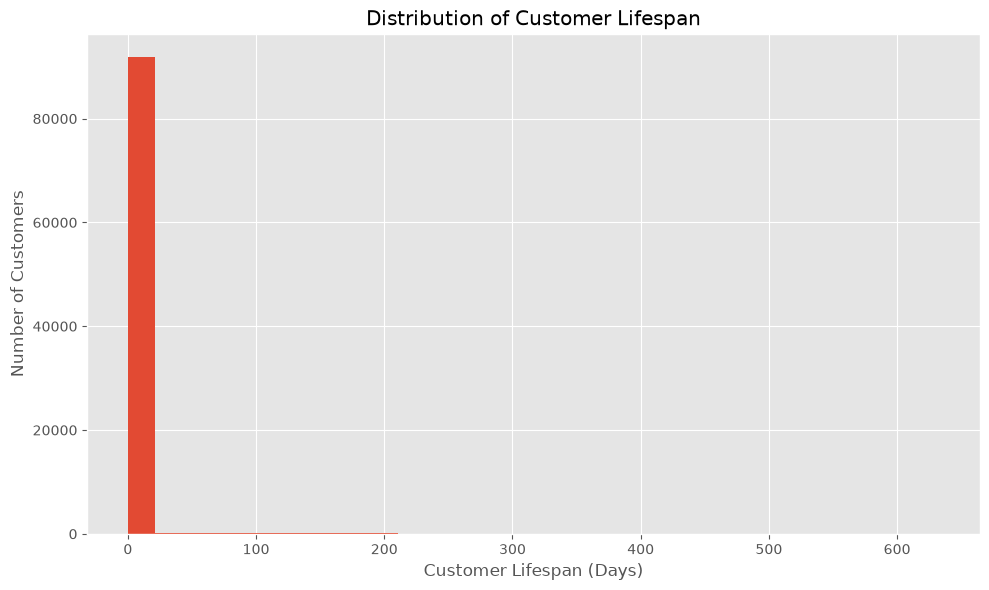

In [10]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_summary["Customer_Lifespan"],
    bins=30
)

plt.title("Distribution of Customer Lifespan")
plt.xlabel("Customer Lifespan (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Business Insight

The customer lifespan distribution is highly right-skewed, with most customers having a lifespan of zero days. This indicates that the majority of customers made only a single purchase during the observation period.

The median customer lifespan is zero days, and at least 75% of customers did not return to make another purchase. Only a relatively small proportion of customers remained active over longer periods, resulting in a long tail extending to more than 600 days.

These findings suggest that customer retention represents a major opportunity for the business. While the company successfully acquires new customers, relatively few continue purchasing over time. Increasing repeat purchases and extending customer lifespan could substantially improve long-term customer value and overall profitability.

### The filtered histogram to analyze the behavior of returning customers.
This chart below focuses only on customers who made more than one purchase, making it much easier to understand how long repeat customers remain active.

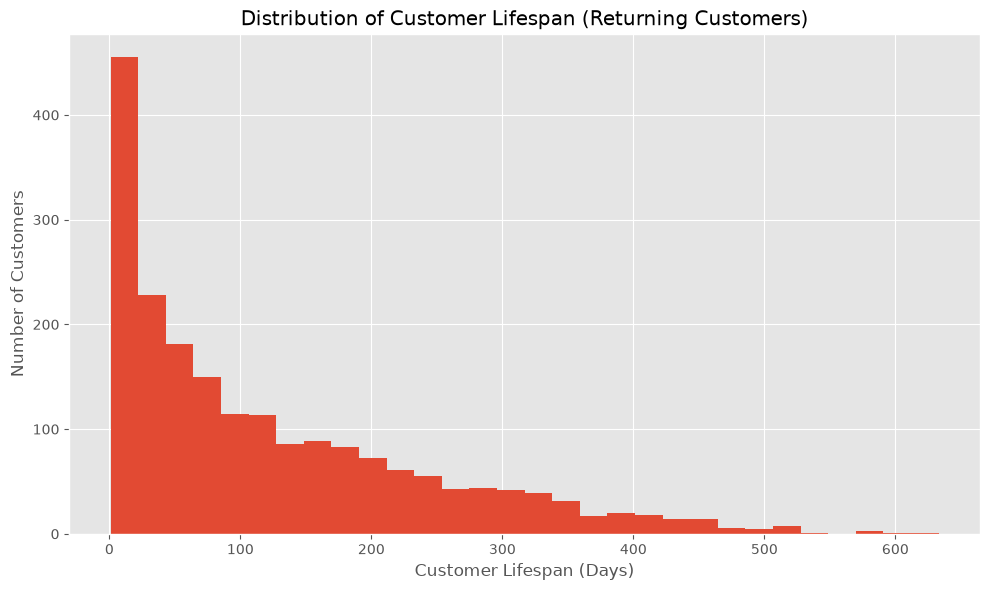

In [11]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_summary.loc[
        customer_summary["Customer_Lifespan"] > 0,
        "Customer_Lifespan"
    ],
    bins=30
)

plt.title("Distribution of Customer Lifespan (Returning Customers)")
plt.xlabel("Customer Lifespan (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Business Insight

After excluding one-time customers, the customer lifespan distribution remains right-skewed. Most returning customers make additional purchases within a relatively short period after their first order, while the number of active customers gradually decreases as customer lifespan increases.

Only a small proportion of customers continue purchasing over extended periods, with some remaining active for more than 600 days. These long-term customers are likely to contribute disproportionately to overall revenue and customer lifetime value.

This finding highlights the importance of retaining existing customers. Extending customer relationships beyond the initial purchase can significantly increase long-term revenue and improve overall business performance.

## Calculate Historical Customer Lifetime Value (CLV)

Customer Lifetime Value (CLV) represents the total value a customer has generated for the business during the observed period.

For this project, a **historical CLV** approach is adopted, where each customer's lifetime value is measured using the total revenue generated from all completed purchases within the dataset. Unlike predictive CLV models, this approach focuses on realized customer value rather than forecasting future purchasing behaviour.

Historical CLV provides a simple, transparent, and interpretable measure of customer value, making it suitable for identifying high-value customers and comparing customer segments.

# Step 8 — Calculate CLV Components

In [25]:
# Average Order Value
customer_summary["Average_Order_Value"] = (
    customer_summary["Total_Revenue"]
    / customer_summary["Total_Orders"]
)

# Purchase Frequency
customer_summary["Purchase_Frequency"] = customer_summary["Total_Orders"]

customer_summary[
    [
        "Total_Revenue",
        "Total_Orders",
        "Average_Order_Value",
        "Purchase_Frequency",
        "Customer_Lifespan"
    ]
].head()

,Total_Revenue,Total_Orders,Average_Order_Value,Purchase_Frequency,Customer_Lifespan
3724,13440.0,1,13440.0,1,0
79636,7388.0,2,3694.0,2,0
43168,7160.0,1,7160.0,1,0
80463,6735.0,1,6735.0,1,0
25436,6729.0,1,6729.0,1,0


# Step 9 — Calculate Historical CLV

In [28]:
customer_summary["Adjusted_Lifespan"] = (
    customer_summary["Customer_Lifespan"]
    .clip(lower=1)
)

# Historical Customer Lifetime Value (Observed Customer Value)
customer_summary["Historical_CLV"] = customer_summary["Total_Revenue"]

customer_summary.head()

,customer_unique_id,Total_Revenue,Total_Orders,First_Purchase,Last_Purchase,Customer_Lifespan,Average_Order_Value,Purchase_Frequency,Adjusted_Lifespan,Historical_CLV
3724,0a0a92112bd4c708ca5fde585afaa872,13440.0,1,2017-09-29 15:24:52,2017-09-29 15:24:52,0,13440.0,1,1,13440.0
79636,da122df9eeddfedc1dc1f5349a1a690c,7388.0,2,2017-04-01 15:58:40,2017-04-01 15:58:41,0,3694.0,2,1,7388.0
43168,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,1,2018-07-15 14:49:44,2018-07-15 14:49:44,0,7160.0,1,1,7160.0
80463,dc4802a71eae9be1dd28f5d788ceb526,6735.0,1,2017-02-12 20:37:36,2017-02-12 20:37:36,0,6735.0,1,1,6735.0
25436,459bef486812aa25204be022145caa62,6729.0,1,2018-07-25 18:10:17,2018-07-25 18:10:17,0,6729.0,1,1,6729.0


In [29]:
customer_summary["Historical_CLV"].describe().round(2)

count    93358.00
mean       141.62
std        215.69
min          0.85
25%         47.65
50%         89.73
75%        154.74
max      13440.00
Name: Historical_CLV, dtype: float64

## Customer Lifetime Value Distribution

Understanding how customer lifetime value is distributed helps identify whether customer value is concentrated among a small number of customers or spread evenly across the customer base.

The following analysis examines the distribution of historical CLV and highlights the presence of high-value customers.

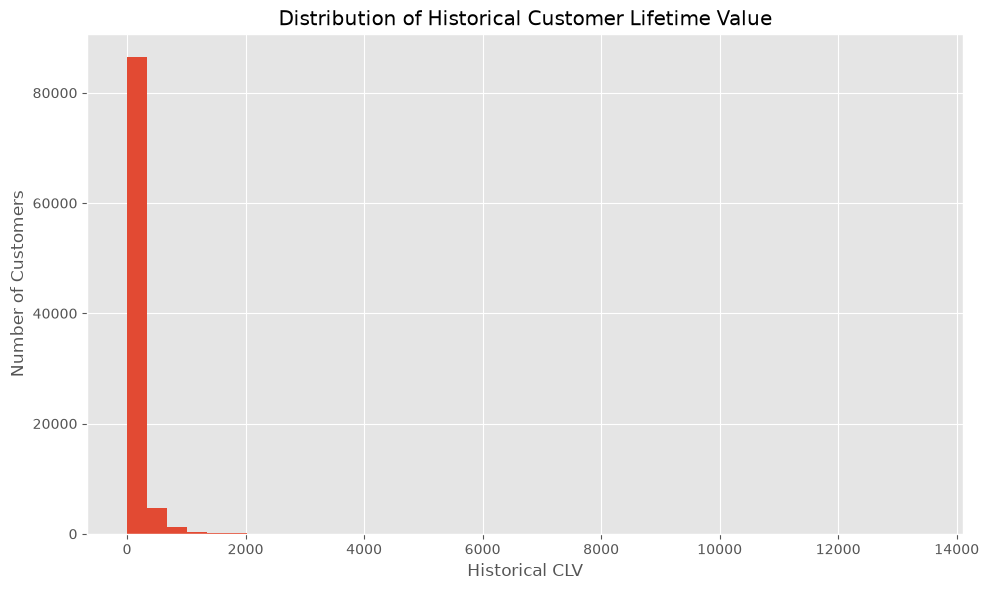

In [30]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_summary["Historical_CLV"],
    bins=40
)

plt.title("Distribution of Historical Customer Lifetime Value")
plt.xlabel("Historical CLV")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

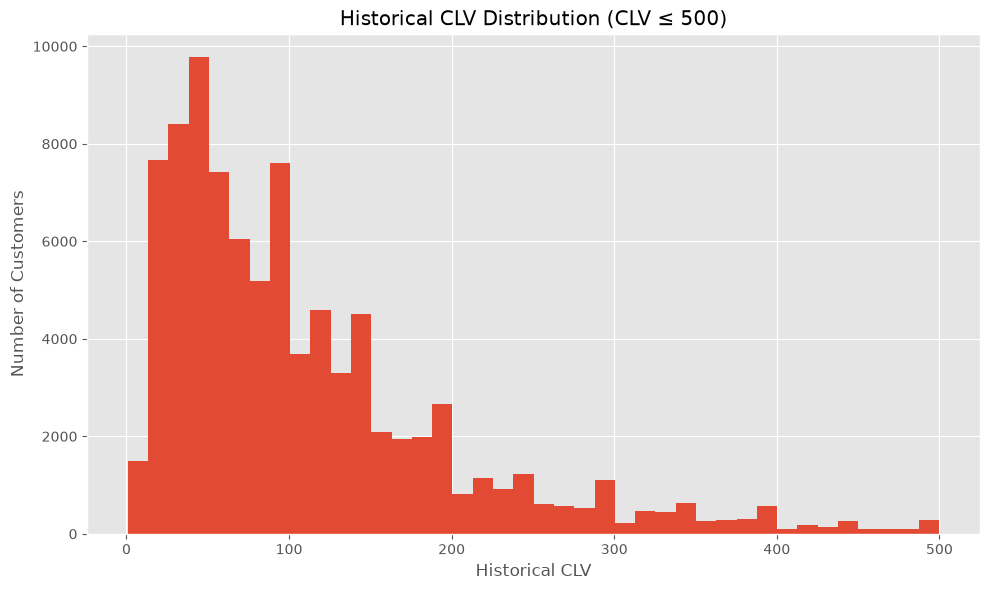

In [31]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_summary.loc[
        customer_summary["Historical_CLV"] <= 500,
        "Historical_CLV"
    ],
    bins=40
)

plt.title("Historical CLV Distribution (CLV ≤ 500)")
plt.xlabel("Historical CLV")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## CLV Quartiles

In [33]:
customer_summary["CLV_Segment"] = pd.qcut(
    customer_summary["Historical_CLV"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "VIP"
    ]
)

clv_summary = (
    customer_summary
    .groupby("CLV_Segment", observed=True)
    .agg(
        Customers=("customer_unique_id", "count"),
        Average_CLV=("Historical_CLV", "mean"),
        Total_CLV=("Historical_CLV", "sum")
    )
    .reset_index()
)

clv_summary["Revenue_Share (%)"] = (
    clv_summary["Total_CLV"]
    / clv_summary["Total_CLV"].sum()
    * 100
).round(2)

clv_summary

,CLV_Segment,Customers,Average_CLV,Total_CLV,Revenue_Share (%)
0,Low,23341,29.101072,679248.11,5.14
1,Medium,23338,65.430433,1527015.44,11.55
2,High,23339,117.735007,2747817.32,20.78
3,VIP,23340,354.216677,8267417.24,62.53


### Business Insight

Customers were segmented into four equally sized groups based on their historical Customer Lifetime Value (CLV). While each segment contains approximately 25% of the customer base, their contribution to total customer value differs substantially.

The **VIP** segment contributes **62.53%** of the total historical customer value, making it the most economically important customer group. In contrast, the **Low CLV** segment contributes only **5.14%**, despite containing the same number of customers.

This finding demonstrates that customer value is highly concentrated among a relatively small group of high-value customers. As a result, businesses should prioritize retaining and engaging VIP customers through personalized experiences, loyalty programs, and premium services, while developing strategies to move Medium and High CLV customers into the VIP segment over time.

## Customer Lifetime Value by RFM Segment

Customer Lifetime Value (CLV) measures the monetary value generated by each customer, while RFM segmentation groups customers according to their purchasing behaviour.

Combining these two approaches provides a deeper understanding of customer value by revealing whether the most engaged customer segments also generate the highest lifetime value. This analysis helps identify which behavioural segments should be prioritized for retention and marketing investment.

### Load the RFM Segments

In [37]:
# Load RFM segmentation from Notebook 03
rfm = pd.read_csv("../outputs/rfm_segments.csv")

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RF_Score,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,41,Promising
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,41,Promising
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,11,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,21,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,21,Hibernating


### Merge CLV and RFM Data

In [38]:
clv_rfm = customer_summary.merge(
    rfm[["customer_unique_id", "Customer_Segment"]],
    on="customer_unique_id",
    how="left"
)

clv_rfm.head()

,customer_unique_id,Total_Revenue,Total_Orders,First_Purchase,Last_Purchase,Customer_Lifespan,Average_Order_Value,Purchase_Frequency,Adjusted_Lifespan,Historical_CLV,CLV_Segment,Customer_Segment
0,0a0a92112bd4c708ca5fde585afaa872,13440.0,1,2017-09-29 15:24:52,2017-09-29 15:24:52,0,13440.0,1,1,13440.0,VIP,Hibernating
1,da122df9eeddfedc1dc1f5349a1a690c,7388.0,2,2017-04-01 15:58:40,2017-04-01 15:58:41,0,3694.0,2,1,7388.0,VIP,Cannot Lose Them
2,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,1,2018-07-15 14:49:44,2018-07-15 14:49:44,0,7160.0,1,1,7160.0,VIP,Potential Loyalists
3,dc4802a71eae9be1dd28f5d788ceb526,6735.0,1,2017-02-12 20:37:36,2017-02-12 20:37:36,0,6735.0,1,1,6735.0,VIP,Cannot Lose Them
4,459bef486812aa25204be022145caa62,6729.0,1,2018-07-25 18:10:17,2018-07-25 18:10:17,0,6729.0,1,1,6729.0,VIP,Potential Loyalists


In [39]:
print(clv_rfm.shape)

print("\nMissing Customer Segments:")
print(clv_rfm["Customer_Segment"].isna().sum())

(93358, 12)

Missing Customer Segments:
0


## Historical CLV by RFM Segment

This analysis combines Customer Lifetime Value (CLV) with RFM segmentation to evaluate the monetary value generated by each behavioural customer segment.

By comparing average and total CLV across RFM segments, we can identify which customer groups contribute the most value and determine where customer retention and marketing efforts should be focused.

### Create the Summary Table

In [40]:
rfm_clv_summary = (
    clv_rfm
    .groupby("Customer_Segment", observed=True)
    .agg(
        Customers=("customer_unique_id", "count"),
        Average_CLV=("Historical_CLV", "mean"),
        Median_CLV=("Historical_CLV", "median"),
        Total_CLV=("Historical_CLV", "sum")
    )
    .reset_index()
)

rfm_clv_summary["Revenue_Share (%)"] = (
    rfm_clv_summary["Total_CLV"]
    / rfm_clv_summary["Total_CLV"].sum()
    * 100
).round(2)

rfm_clv_summary = rfm_clv_summary.sort_values(
    by="Average_CLV",
    ascending=False
)

rfm_clv_summary

,Customer_Segment,Customers,Average_CLV,Median_CLV,Total_CLV,Revenue_Share (%)
3,Champions,7535,149.320491,91.900,1125129.90,8.51
6,Loyal Customers,15005,145.525174,94.000,2183605.24,16.52
1,At Risk,11150,145.463627,89.900,1621919.44,12.27
2,Cannot Lose Them,7376,145.054652,89.900,1069923.11,8.09
10,Promising,3759,142.869553,88.900,537046.65,4.06
9,Potential Loyalists,14993,140.934566,89.100,2113031.95,15.98
4,Hibernating,14863,139.920252,84.990,2079634.71,15.73
5,Lost,3827,139.096010,89.000,532320.43,4.03
8,New Customers,3720,135.492806,89.000,504033.24,3.81
0,About to Sleep,3710,132.661987,88.895,492175.97,3.72


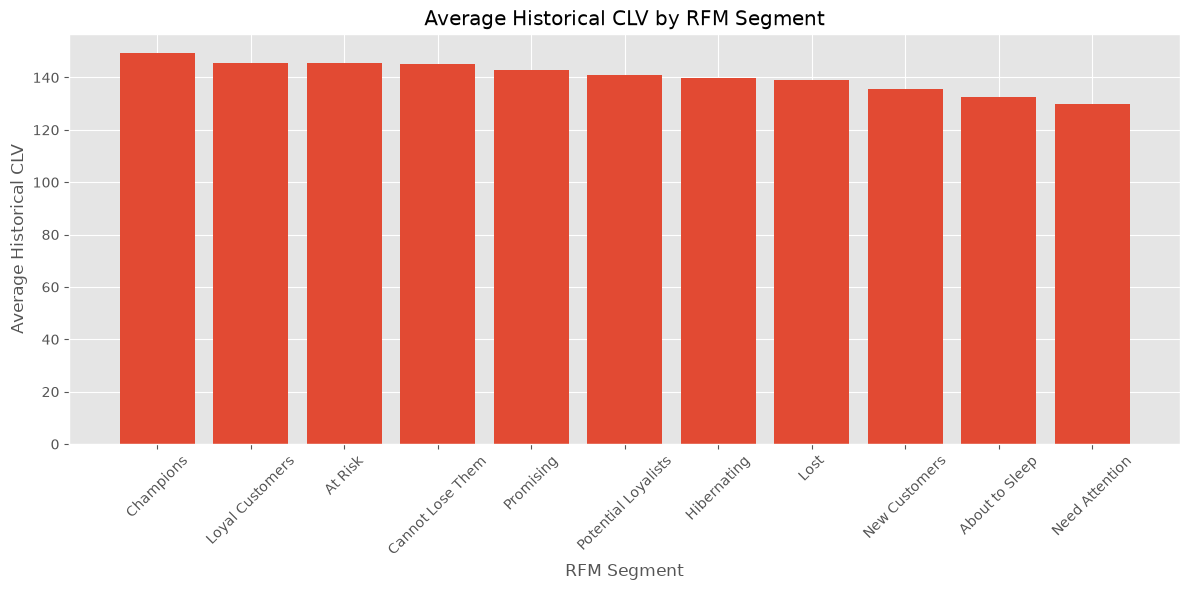

In [41]:
plt.figure(figsize=(12,6))

plt.bar(
    rfm_clv_summary["Customer_Segment"],
    rfm_clv_summary["Average_CLV"]
)

plt.title("Average Historical CLV by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Average Historical CLV")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

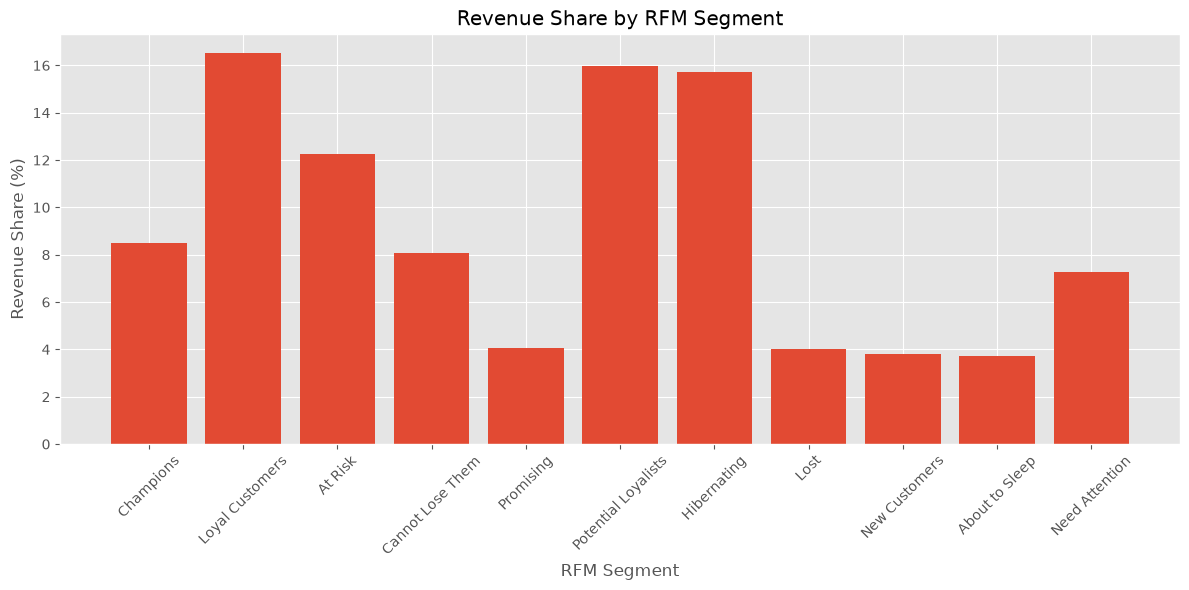

In [42]:
plt.figure(figsize=(12,6))

plt.bar(
    rfm_clv_summary["Customer_Segment"],
    rfm_clv_summary["Revenue_Share (%)"]
)

plt.title("Revenue Share by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Revenue Share (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights

Integrating Customer Lifetime Value (CLV) with RFM segmentation provides a more comprehensive understanding of customer value than either approach alone.

Although **Champions** have the highest average historical CLV (149.32), **Loyal Customers** contribute the largest share of total customer value (16.52%) due to their larger customer base. This indicates that maintaining strong relationships with loyal customers can have a substantial impact on overall business performance.

The analysis also highlights the importance of customer retention. The **At Risk** segment contributes 12.27% of total historical customer value, while **Hibernating** customers account for 15.73%. Together, these segments represent a significant proportion of historical revenue, suggesting that effective re-engagement strategies could help recover valuable customers before they are permanently lost.

Overall, the findings demonstrate that customer behaviour and customer value are closely related but not identical. While Champions represent the highest-value customers on average, Loyal Customers generate the greatest overall contribution to business revenue because of their larger population.

## Strategic Business Recommendations

The Customer Lifetime Value (CLV) analysis provides actionable insights into how businesses can allocate marketing resources and improve customer retention strategies. By combining CLV with RFM segmentation, different customer groups can be targeted with tailored engagement strategies to maximize long-term business value.

In [43]:
recommendations = pd.DataFrame({
    "Customer Segment": [
        "Champions",
        "Loyal Customers",
        "Potential Loyalists",
        "At Risk",
        "Cannot Lose Them",
        "Need Attention",
        "Hibernating",
        "New Customers",
        "Promising",
        "About to Sleep",
        "Lost"
    ],
    "Business Recommendation": [
        "Reward with exclusive loyalty benefits and premium experiences.",
        "Maintain engagement through personalized offers and loyalty programs.",
        "Encourage repeat purchases using targeted promotions and recommendations.",
        "Launch retention campaigns before customers churn.",
        "Provide personalized incentives to recover valuable customers.",
        "Increase engagement through reminder emails and tailored promotions.",
        "Re-engage with win-back campaigns and limited-time offers.",
        "Deliver an excellent onboarding experience and encourage second purchases.",
        "Nurture with personalized product recommendations.",
        "Send timely reminders and promotional offers before inactivity increases.",
        "Evaluate the cost-effectiveness of reactivation campaigns."
    ]
})

recommendations

,Customer Segment,Business Recommendation
0,Champions,Reward with exclusive loyalty benefits and pre...
1,Loyal Customers,Maintain engagement through personalized offer...
2,Potential Loyalists,Encourage repeat purchases using targeted prom...
3,At Risk,Launch retention campaigns before customers ch...
4,Cannot Lose Them,Provide personalized incentives to recover val...
5,Need Attention,Increase engagement through reminder emails an...
6,Hibernating,Re-engage with win-back campaigns and limited-...
7,New Customers,Deliver an excellent onboarding experience and...
8,Promising,Nurture with personalized product recommendati...
9,About to Sleep,Send timely reminders and promotional offers b...


### Key Recommendations

Based on the historical CLV and RFM analyses, the following business actions are recommended:

- Retain **Champions** and **Loyal Customers** through loyalty programs and personalized experiences.
- Prioritize retention efforts for **At Risk** and **Cannot Lose Them** customers, as they represent a substantial share of historical customer value.
- Develop targeted campaigns to convert **Potential Loyalists** into long-term high-value customers.
- Implement reactivation campaigns for **Hibernating** customers who have previously generated significant revenue.
- Improve onboarding and early engagement strategies to encourage **New Customers** to become repeat purchasers.

## Save Outputs

The final Customer Lifetime Value dataset is saved for use in subsequent notebooks, including customer retention analysis and predictive modeling.

In [44]:
customer_summary.to_csv(
    "../outputs/customer_clv.csv",
    index=False
)

print("Customer CLV dataset saved successfully.")

Customer CLV dataset saved successfully.


# Conclusion

This notebook analyzed historical Customer Lifetime Value (CLV) using the Olist Brazilian E-Commerce dataset to identify customers who generated the greatest economic value during the observation period.

### Key Findings

- Historical CLV was calculated as the total revenue generated by each customer across all completed purchases.
- Customers were segmented into four CLV tiers (Low, Medium, High, and VIP), revealing that the **VIP segment contributed 62.53% of the total historical customer value**, despite representing only one-quarter of the customer base.
- Combining CLV with RFM segmentation showed that **Champions** had the highest average customer value, while **Loyal Customers** generated the largest share of total historical value due to their larger population.
- The analysis also identified **At Risk** and **Hibernating** customers as strategically important segments, highlighting opportunities for targeted retention and re-engagement initiatives.

### Business Value

The findings demonstrate that customer value is highly concentrated among a relatively small proportion of customers. Integrating monetary value with customer behavior enables organizations to prioritize marketing investments, improve retention strategies, and allocate resources more effectively.

The exported CLV dataset will serve as the foundation for the next stage of the project, where customer retention patterns and churn-related behavior will be analyzed.